# Part 2: FALCON — Active Learning for Machine Learning Potentials

## What We Just Did (Parts 1a–1c)

We built a neural network that learns a PES from a **fixed dataset**.

But where did that dataset come from? We just sampled the Morse potential
analytically. In real research, every data point costs a DFT calculation.

## The Active Learning Question

> *"How do we decide WHICH DFT calculations to run?"*

This is the core problem that FALCON solves.

## What We'll Cover

1. What FALCON is (and isn't)
2. The FALCON API: parameter by parameter
3. Why GPR for uncertainty (not a NN)
4. Live demo: GPR uncertainty visualization
5. Live demo: clustering training data
6. The OTF loop
7. Connection to your Li₃OCl/Br research

## The Key Insight

Instead of training one giant model on ALL data:
→ Cluster the data into subsets
→ Train K smaller models (one per cluster)
→ During MD, use the model with lowest uncertainty
→ If uncertain, call DFT, add to cluster, retrain ONLY that model

This is **active learning**.

## What FALCON Is

FALCON is an **ASE Calculator wrapper** that sits between your MD engine
and your exact calculator.

### It Is NOT:
- ❌ A new ML model (it uses GPR, not a novel architecture)
- ❌ A LAMMPS plugin (it's ASE-based)
- ❌ A replacement for DFT (it calls DFT when needed)
- ❌ A neural network framework (see Parts 1a–1c for that)

### It IS:
- ✅ An on-the-fly (OTF) active learning orchestrator
- ✅ A clustering-based multi-model framework
- ✅ A drop-in calculator for ASE MD simulations
- ✅ CPU-friendly (no GPU required)

### The Core Idea

Traditional approach:

1. Run 1000 DFT calculations
2. Train one big ML model
3. Run MD with that model

FALCON approach:

1. Run 10 DFT calculations (initial training data)
2. Start MD with an ML model
3. During MD, if the model is uncertain → run 1 DFT → retrain
4. Repeat until the model is confident everywhere it visits

**This is "on-the-fly" learning: the model grows during the simulation.**

## The FALCON API: Three Lines of Code

Here's the entire setup:

Before import, install with a pip command (and a C++ compiler; I used Microsoft's VS 2026 Build Tools with C++ workload).

In [1]:
# !pip install falcon-md

Patch for Windows environment:

In [2]:
import os

# AGOX calls os.sched_getaffinity, which doesn't exist on Windows
if not hasattr(os, "sched_getaffinity"):
    os.sched_getaffinity = lambda pid: set(range(os.cpu_count() or 1))

# Ray's default startup timeout is too short on Windows
os.environ["RAY_raylet_start_wait_time_s"] = "120"

# Silence some joblib/KMeans warnings on Windows
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

And then we set up. Start by generating initial training data. We'll be using a 3x3x3 Pt fcc supercell and rattle it so it's not perfectly symmetric. (Perfect symmetry gives degenerate initial dataset. Diversity is key.) Then, a short optimization produces some slightly different structures that seed the GPR. It won't fully converge, but that's intentional.

In [3]:
from ase.build import bulk
from ase.calculators.emt import EMT
from ase.optimize import QuasiNewton
from ase.io import read

atoms = bulk("Pt", "fcc", a=3.92, cubic=True).repeat((3, 3, 3))
atoms.rattle(0.1)

atoms.calc = EMT()
qn = QuasiNewton(atoms, trajectory="opt.traj")
qn.run(fmax=0.05)

initial_data = read("opt.traj", index=":")
print(f"Number of initial structures: {len(initial_data)}")

                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 20:19:02       14.894293       8.3459
BFGSLineSearch:    1[  1] 20:19:02        5.372043       1.8596
BFGSLineSearch:    2[  2] 20:19:02        1.779235       3.8814
BFGSLineSearch:    3[  3] 20:19:02        0.344974       0.5983
BFGSLineSearch:    4[  4] 20:19:02        0.107853       0.2303
BFGSLineSearch:    5[  5] 20:19:02        0.036441       0.1090
BFGSLineSearch:    6[  6] 20:19:02        0.002594       0.0628
BFGSLineSearch:    7[  7] 20:19:02       -0.007350       0.0527
BFGSLineSearch:    8[  8] 20:19:02       -0.011832       0.0312
Number of initial structures: 9


Now we build the FALCON calculator. (We're using AGOX instead of Ray, which is only a technical detail that's different from the FALCON paper, but I need it to run on Windows.)

First, we build the descriptor and kernel exactly as `falcon_md.models.agox_models` does, but pass `use_ray=False` to avoid the Ray startup timeout on Windows.

In [4]:
from falcon_md.otf_calculator import FALCON
from falcon_md.models.agox_models import GPR
from ase.calculators.emt import EMT

# GPR is a factory function: give it an Atoms object,
# and it returns a ready-to-use AGOX GPR model.
model = GPR(atoms)

falcon = FALCON(
    model=model,
    calc=EMT(),
    training_data=initial_data,
    accuracy_e=0.10,
    accuracy_f=float("inf"),
    modelsize=200,
    max_clusters=1,
    start_clusters=1,
    train_start=10,
    train_every=1e9,
    train_log=True,
    i_batch=1,
    write_training_data=True,
    td_filename="OTF_Training_Data.traj",
)

Using C:\Users\carli/tmp/ray as Ray temporary folder because the given or generated path is too long.


2026-09-22 20:19:14,539	INFO worker.py:2024 -- Started a local Ray instance.


Ray Resources
	CPU = 12.0
	object_store_memory = 6000000000.0
	node:127.0.0.1 = 1.0
	memory = 24000000000.0
	node:__internal_head__ = 1.0
Attempt 0: Pool started successfully.


(raylet) Stack (most recent call first):
(raylet)   File "C:\Users\carli\AppData\Local\miniconda\envs\ci\Lib\site-packages\ray\_private\worker.py", line 627 in job_logging_config
(raylet)   File "C:\Users\carli\AppData\Local\miniconda\envs\ci\Lib\site-packages\ray\_private\worker.py", line 2807 in disconnect
(raylet)   File "C:\Users\carli\AppData\Local\miniconda\envs\ci\Lib\site-packages\ray\_private\worker.py", line 2118 in shutdown
(raylet)   File "C:\Users\carli\AppData\Local\miniconda\envs\ci\Lib\site-packages\ray\_private\worker.py", line 1170 in wrapper
(raylet)   File "C:\Users\carli\AppData\Local\miniconda\envs\ci\Lib\site-packages\ray\_private\client_mode_hook.py", line 134 in wrapper



You are using the Gaussian Process Regression model implemented in AGOX. If you use this model in a publication, please cite:
Mads-Peter V. Christiansen, Nikolaj Rønne, Bjørk Hammer, "Atomistic Global Optimization X: A Python package for optimization of atomistic structures", J. Chem. Phys. 157, 054701 (2022),
<https://arxiv.org/abs/2204.01451>

If you are using FALCON in a publication, please cite: 
 Felis, N., Dononelli, W. (2025). FALCON: fast active learning for machine learning potentials in atomistic and ab initio molecular dynamics simulations. npj Comput. Mater., https://doi.org/10.1038/s41524-025-01897-8


Now, we verify the FALCON signature.

In [5]:
import inspect
from falcon_md.otf_calculator import FALCON

print(inspect.signature(FALCON.__init__))

(self, model, calc, training_data, accuracy_e=0.1, accuracy_f=inf, accuracy_update=0.0, modelsize=500, max_clusters=1, start_clusters=1, train_start=10, train_every=1000000000.0, train_log=True, i_batch=1, write_training_data=True, td_filename='OTF_Training_Data.traj', **kwargs)


### Parameter-by-Parameter Breakdown

| Parameter | What It Does | Our Value |
|:---|:---|:---|
| `model` | The surrogate ML model | `GPR(atoms)` |
| `exact_calc` | Ground-truth calculator | `EMT()` |
| `training_data` | Starting dataset | From geometry optimization |
| `accuracy_e` | Uncertainty threshold (eV) | `0.10` |
| `model_size` | Structures per cluster | `200` |

### What Each Parameter Means Physically

- **`accuracy_e = 0.10 eV`**: "If the model's uncertainty exceeds 0.10 eV, call DFT."
  - Lower ε → more DFT calls → more accurate model
  - Higher ε → fewer DFT calls → faster but less accurate

- **`model_size = 200`**: "Keep each GPR model to ~200 training structures."
  - Smaller → faster per-training, more frequent retraining
  - Larger → slower per-training, fewer retraining events

- **`model = GPR(atoms)`**: The surrogate model. We'll discuss why GPR in a moment.

## Why GPR for Active Learning?

In Part 1c, we used a neural network. Why does FALCON use Gaussian process regression (GPR)?

### The Key Difference: Uncertainty Quantification

| Feature | Neural Network | Gaussian Process Regression |
|:---|:---|:---|
| **Uncertainty** | Needs ensemble (train 5+ models) | Native (predictive variance) |
| **Data efficiency** | Needs 1000+ structures | Works well with <500 |
| **Training speed** | Fast with GPU, slow on CPU | Fast for small data, cubic scaling |
| **Force computation** | Autograd | Analytical gradient |
| **Hardware** | GPU preferred | CPU |

### The Deciding Factor: Uncertainty

For **active learning**, you need to know:
> *"How confident is the model about this prediction?"*

- **NN approach:** Train 5 models with different seeds, use their disagreement as uncertainty
- **GPR approach:** The model gives you a variance directly, no ensemble needed

For a workshop running on laptops, GPR is simpler and faster to set up.

### But Wait — I Just Built a Neural Network!

**You did, and that's valuable.** Neural networks are used in production MLFFs
(MACE, NequIP, SchNet) because they scale better.

FALCON uses GPR because:
1. It's CPU-friendly (no GPU needed)
2. It gives uncertainty for free
3. It's data-efficient (works with <500 structures)
4. It's perfect for a workshop demo

**In production, you'd train a MACE model using FALCON's data.**

## Visualizing GPR Uncertainty

GPR gives us two things for every prediction:
1. **Mean prediction** (best estimate)
2. **Standard deviation** (how confident it is)

The uncertainty is what drives FALCON's active learning:
- Low uncertainty → trust the model, continue MD
- High uncertainty → call DFT, add to training data

This cell doesn't use FALCON. We'll be using Gaussian Process Regressor.

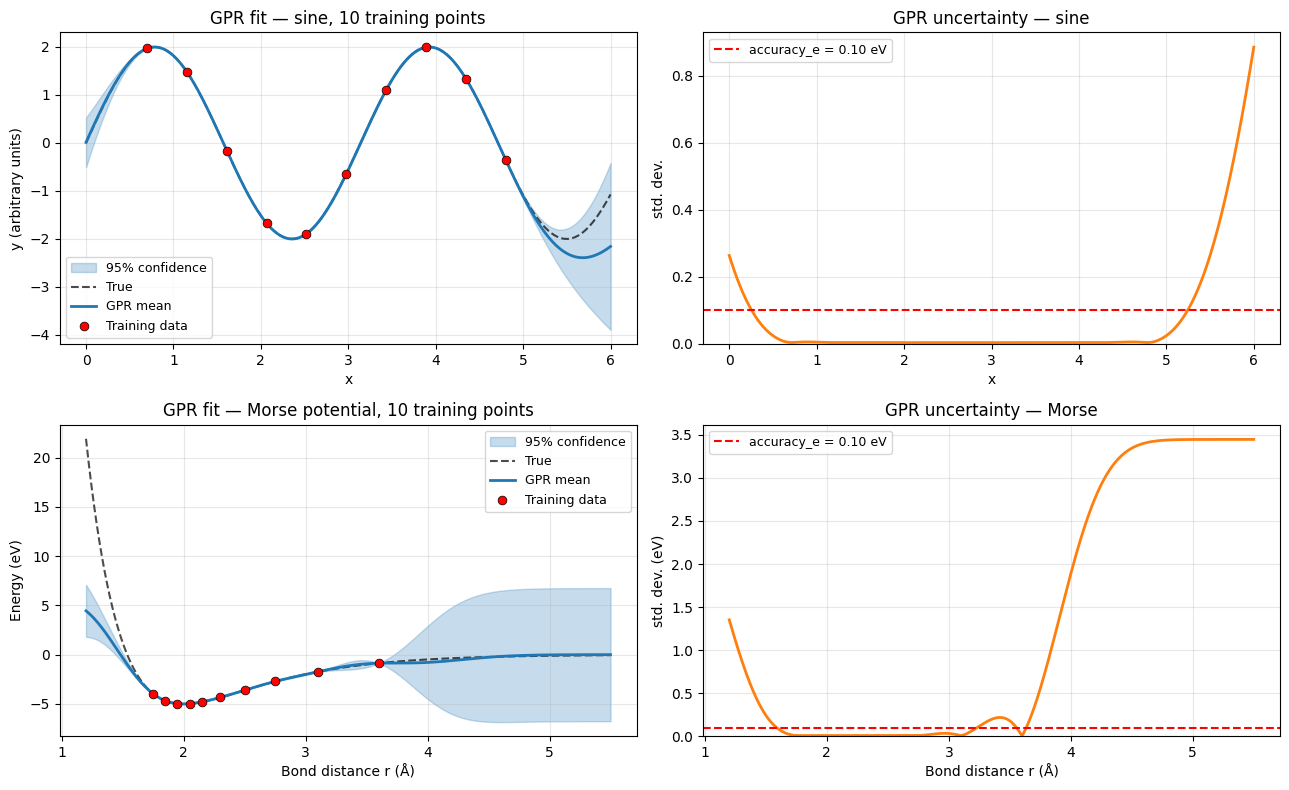

In [6]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
np.random.seed(42)

# ---------------------------------------------------------------
# Ground-truth functions
# ---------------------------------------------------------------
def sine_truth(x):
    return 2.0 * np.sin(2.0 * x)

def morse_truth(r, De=5.0, a=1.5, re=2.0):
    return De * (1 - np.exp(-a * (r - re)))**2 - De

# ---------------------------------------------------------------
# Training data: 10 points each, chosen to show both interpolation
# and extrapolation behavior.
# ---------------------------------------------------------------
# Sine: evenly spaced across most of the plotted window.
x_sine_train = np.linspace(0.7, 4.8, 10)
y_sine_train = sine_truth(x_sine_train)

# Morse: clustered in the well. The repulsive wall (r < 1.75) and the
# dissociative tail (r > 3.6) are deliberately left unsampled.
r_morse_train = np.array(
    [1.75, 1.85, 1.95, 2.05, 2.15, 2.30, 2.50, 2.75, 3.10, 3.60]
)
E_morse_train = morse_truth(r_morse_train)

# ---------------------------------------------------------------
# Helper: fit a GPR and return predictions + uncertainty on a grid.
# Same kernel for both problems so the comparison is fair.
# ---------------------------------------------------------------
def fit_gpr(x_train, y_train, x_grid):
    X = x_train.reshape(-1, 1)
    Y = y_train
    kernel = (
        ConstantKernel(1.0, (1e-2, 1e3))
        * RBF(length_scale=1.0, length_scale_bounds=(0.1, 10.0))
        + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 1e-1))
    )
    gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
    gpr.fit(X, Y)
    xg = x_grid.reshape(-1, 1)
    mean, std = gpr.predict(xg, return_std=True)
    return mean, std

# ---------------------------------------------------------------
# Predictions
# ---------------------------------------------------------------
x_sine_grid = np.linspace(0.0, 6.0, 400)
sine_mean, sine_std = fit_gpr(x_sine_train, y_sine_train, x_sine_grid)
sine_true = sine_truth(x_sine_grid)

r_morse_grid = np.linspace(1.2, 5.5, 400)
morse_mean, morse_std = fit_gpr(r_morse_train, E_morse_train, r_morse_grid)
morse_true = morse_truth(r_morse_grid)

# ---------------------------------------------------------------
# Plot
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

def plot_fit(ax, x, true, mean, std, x_train, y_train, title, ylabel):
    ax.fill_between(
        x, mean - 1.96 * std, mean + 1.96 * std,
        color="C0", alpha=0.25, label="95% confidence",
    )
    ax.plot(x, true, "k--", lw=1.5, alpha=0.7, label="True")
    ax.plot(x, mean, "C0-", lw=2, label="GPR mean")
    ax.scatter(x_train, y_train, color="red", zorder=5, s=40,
               edgecolors="black", linewidths=0.5, label="Training data")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)

def plot_uncertainty(ax, x, std, title, ylabel):
    ax.plot(x, std, color="C1", lw=2)
    ax.axhline(0.10, color="r", ls="--", label="accuracy_e = 0.10 eV")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

# Row 1: sine
plot_fit(
    axes[0, 0], x_sine_grid, sine_true, sine_mean, sine_std,
    x_sine_train, y_sine_train,
    "GPR fit — sine, 10 training points",
    "y (arbitrary units)",
)
plot_uncertainty(
    axes[0, 1], x_sine_grid, sine_std,
    "GPR uncertainty — sine",
    "std. dev.",
)
axes[0, 0].set_xlabel("x")
axes[0, 1].set_xlabel("x")

# Row 2: Morse
plot_fit(
    axes[1, 0], r_morse_grid, morse_true, morse_mean, morse_std,
    r_morse_train, E_morse_train,
    "GPR fit — Morse potential, 10 training points",
    "Energy (eV)",
)
plot_uncertainty(
    axes[1, 1], r_morse_grid, morse_std,
    "GPR uncertainty — Morse",
    "std. dev. (eV)",
)
axes[1, 0].set_xlabel("Bond distance r (Å)")
axes[1, 1].set_xlabel("Bond distance r (Å)")

plt.tight_layout()
plt.savefig("gpr_comparison.png", dpi=150)
plt.show()

Notice:
- **Sine:** The training points span most of the plotted range, so the mean tracks the true curve almost perfectly in the interior, and the confidence band is narrow. The uncertainty only rises at the edges — the model knows it's extrapolating past x ≈ 4.8. Even here, though, notice the right panel: σ exceeds the 0.10 eV threshold right at the plot boundaries. That's the "I need more data" signal.
- **Morse:** Inside the well (r ≈ 1.9 to 3.6), GPR is essentially perfect — tight band, mean sits on the true curve. But two things break:
    - Repulsive wall (r < 1.8): GPR's mean stays low and smooth where the true curve shoots upward toward dissociation-repulsion. The confidence band explodes. This is the region where a naive MLFF would let a molecule pass through itself.
    - Deep tail (r > 3.6): The mean gradually peels off from the true asymptote, and the band widens.

## The Clustering Innovation

FALCON's key contribution is **clustering**. Instead of one big GPR model,
it trains K smaller models on K clusters of training data.

### Why Clustering?

GPR training scales as **O(N³)** — cubic in the number of training structures.

If you split N into K clusters of size N/K:
$$\text{Training time} = K \times O((N/K)^3) = O(N^3 / K^2)$$

That's a **quadratic speedup** in the number of clusters!

### Physical Interpretation

In a defected solid, different regions of the PES correspond to:
- **Cluster A:** Pristine lattice (ordered)
- **Cluster B:** Single vacancy + interstitial (disordered)
- **Cluster C:** Displacement cascade core (melted)

Each cluster gets its own specialized model. When new data arrives,
it goes to the cluster it's most similar to, and only THAT model is retrained.

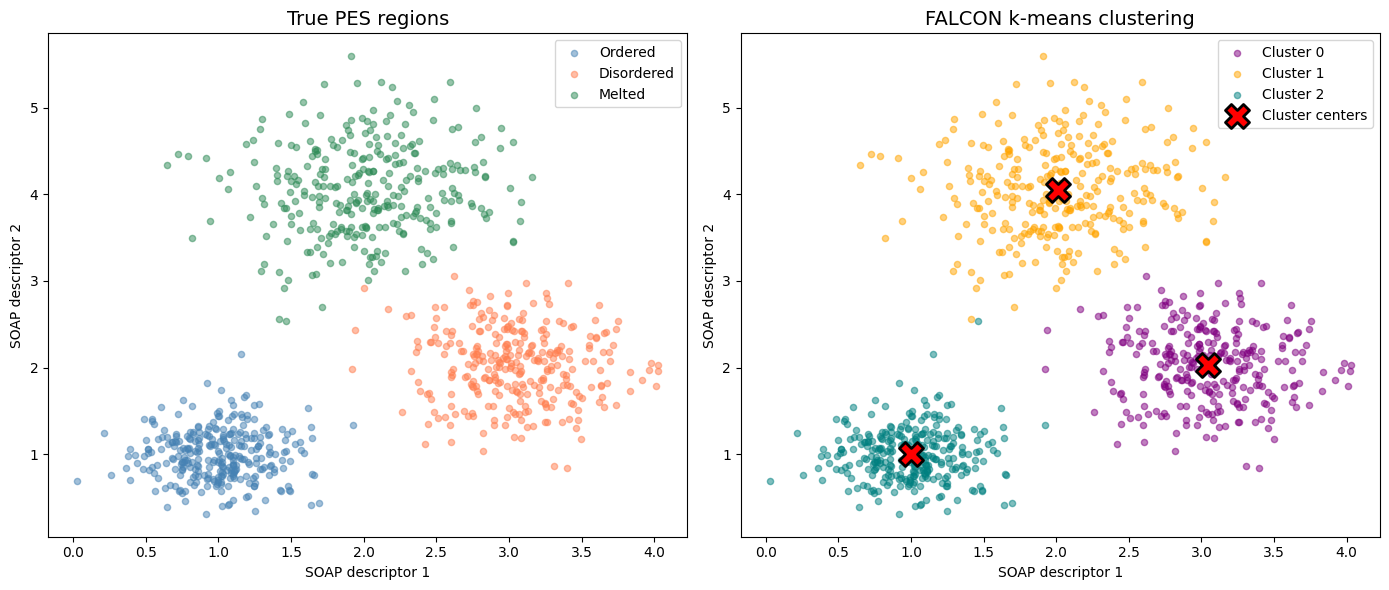

Each cluster gets its own GPR model.
When new data arrives, it goes to the nearest cluster.
Only THAT cluster's model is retrained.


In [7]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ============================================================
# GENERATE FAKE "SOAP DESCRIPTOR" DATA
# ============================================================
# Three distinct regions of PES: ordered, disordered, melted
cluster1 = np.random.randn(300, 2) * 0.3 + [1, 1]    # ordered
cluster2 = np.random.randn(300, 2) * 0.4 + [3, 2]    # disordered
cluster3 = np.random.randn(300, 2) * 0.5 + [2, 4]    # melted

X = np.vstack([cluster1, cluster2, cluster3])
true_labels = np.array([0]*300 + [1]*300 + [2]*300)

# ============================================================
# APPLY K-MEANS (this is what FALCON does internally)
# ============================================================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
pred_labels = kmeans.fit_predict(X)

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# True clusters
colors = ['steelblue', 'coral', 'seagreen']
for i, (color, name) in enumerate(zip(colors, ['Ordered', 'Disordered', 'Melted'])):
    mask = true_labels == i
    axes[0].scatter(X[mask, 0], X[mask, 1], c=color, alpha=0.5, s=20, label=name)
axes[0].set_title('True PES regions', fontsize=14)
axes[0].legend()
axes[0].set_xlabel('SOAP descriptor 1')
axes[0].set_ylabel('SOAP descriptor 2')

# K-means clusters
for i, color in enumerate(['purple', 'orange', 'teal']):
    mask = pred_labels == i
    axes[1].scatter(X[mask, 0], X[mask, 1], c=color, alpha=0.5, s=20,
                    label=f'Cluster {i}')
axes[1].scatter(kmeans.cluster_centers_[:, 0],
                kmeans.cluster_centers_[:, 1],
                c='red', marker='X', s=300, edgecolors='black',
                linewidths=2, label='Cluster centers')
axes[1].set_title('FALCON k-means clustering', fontsize=14)
axes[1].legend()
axes[1].set_xlabel('SOAP descriptor 1')
axes[1].set_ylabel('SOAP descriptor 2')

plt.tight_layout()
plt.savefig('clustering_demo.png', dpi=150)
plt.show()

print("Each cluster gets its own GPR model.")
print("When new data arrives, it goes to the nearest cluster.")
print("Only THAT cluster's model is retrained.")

## What This Means for Research

### Complex Systems: Li₃OCl₍ₓ₎Br₍₁₋ₓ₎ and LiAlO₂

**The challenge:**
- Ionic conductor with long-range electrostatics
- Radiation cascades create rare defect configurations
- DFT is expensive (days per trajectory)
- You need ns–μs timescales

**The FALCON workflow:**

| Phase | What You Do | FALCON Parameter |
|:---|:---|:---|
| **1. Initial data** | Geometry-optimize pristine supercell | `training_data` |
| **2. OTF-MD** | Run short MD at 600 K | `accuracy_e = 0.10` |
| **3. Defect creation** | Create vacancy/interstitial | (happens during MD) |
| **4. Active learning** | FALCON calls DFT at uncertain configs | `model_size = 200` |
| **5. Post-processing** | Extract uncertain structures | FALCON utility |
| **6. Production** | Train MACE on full dataset | (Part 5) |

### Caveats for  System

⚠️ **Long-range electrostatics:** FALCON's GPR uses short-range descriptors.
For Li₃OCl/Br, you need to augment with explicit Coulomb.

⚠️ **Chaotic events:** Radiation cascades are rare and extreme.
You may need a lower ε (more DFT calls) to capture them.

⚠️ **Multi-element systems:** Li, O, Cl, Br, Al → 5 elements.
Use SOAP descriptors with element-specific channels.

### The Bottom Line

FALCON gives us  a **principled way to decide which DFT calculations to run**.
Instead of guessing, you let the model tell you where it's uncertain.

## Common Pitfalls When Using FALCON

| Pitfall | Symptom | Solution |
|:---|:---|:---|
| **ε too small** | Thousands of DFT calls | Increase ε (start with 0.10 eV) |
| **ε too large** | Unphysical MD (exploding) | Decrease ε |
| **model_size too small** | Constant retraining | Increase model_size |
| **model_size too large** | Slow per-step training | Decrease model_size |
| **Bad initial data** | Model never converges | Include diverse configurations |
| **Forgetting forces** | Energy fits, forces are wrong | Use `lambda_force > 0` |

### From the FALCON Paper

> *"For accuracy thresholds of 0.100 eV and above, the ML model initially
> requires frequent retraining. However, after a certain number of training
> steps, a stable state is reached."*

> *"At a threshold of 0.075 eV, the total training time required for 20,000
> MD steps is an order of magnitude higher than at 0.100 eV."*

**Recommendation: Start with ε = 0.10 eV and adjust based on your system.**